<a href="https://colab.research.google.com/github/Madhuanabala/SET/blob/classification/classification_after_lipinsky_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index(['Compound Name', 'Anti-Inflammatory', 'Anti-Oxidant', 'Anti-Cancer',
       'Other Properties'],
      dtype='object')
  Compound Name  Anti-Inflammatory  Anti-Oxidant  Anti-Cancer  \
0      Curcumin                  1             1            0   
1   Resveratrol                  1             1            0   
2      Gingerol                  1             0            0   
3  thymoquinone                  1             0            0   
4       salicin                  1             0            0   

   Other Properties  
0                 1  
1                 1  
2                 0  
3                 0  
4                 0  
Index(['Compound Name', 'Anti-Oxidant', 'Anti-Cancer', 'Other Properties'], dtype='object')
Index(['Compound Name', 'Anti-Inflammatory', 'Anti-Oxidant', 'Anti-Cancer',
       'Other Properties'],
      dtype='object')
  Compound Name  Anti-Inflammatory  Anti-Oxidant  Anti-Cancer  \
0      Curcumin                  1             1            0   
1  

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


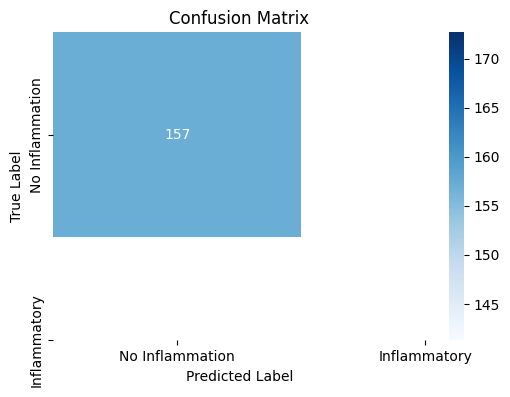

<ipython-input-7-843e63e0af41>:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette="viridis")


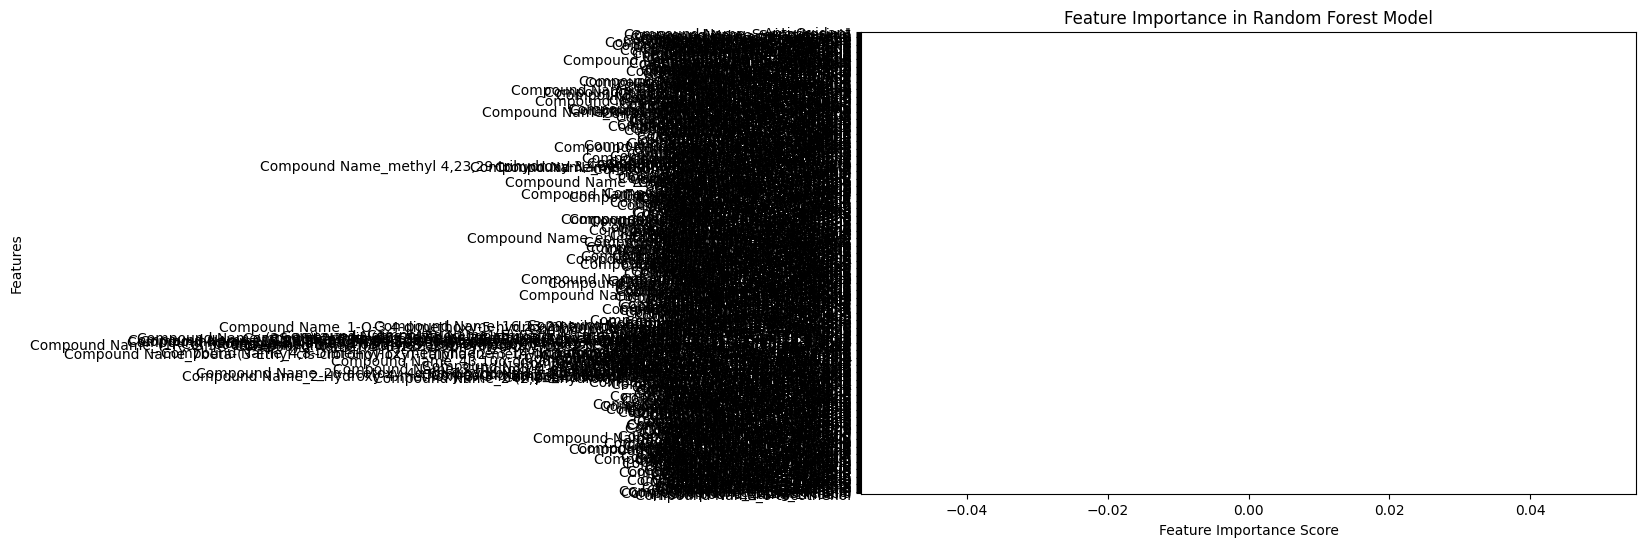

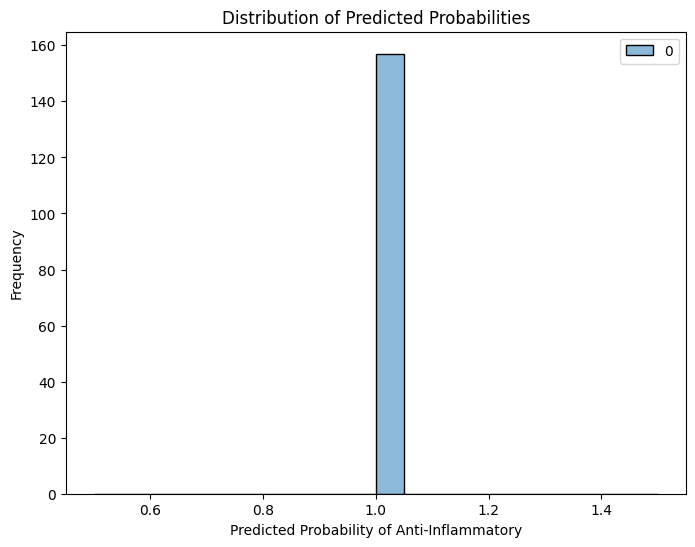

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1174: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


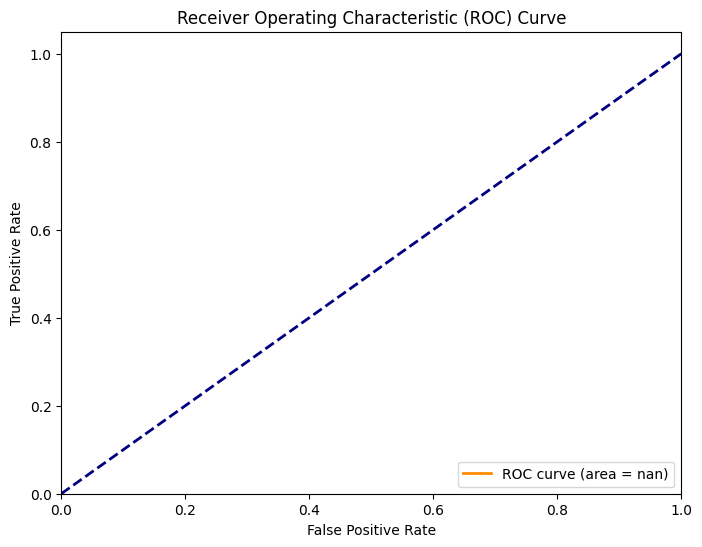

Classification results exported successfully to classification_results.xlsx
Training samples: 364 (69.87%)
Test samples: 157 (30.13%)


In [7]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
file_path = '/content/after lipinksy.xlsx'
data = pd.read_excel(file_path)
print(data.columns)
print(data.head())
y = data['Anti-Inflammatory']
X = X = data[[ 'Compound Name','Anti-Oxidant', 'Anti-Cancer', 'Other Properties']]
print(X.columns)
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder # Import OneHotEncoder
from sklearn.metrics import confusion_matrix
file_path = '/content/after lipinksy.xlsx'
data = pd.read_excel(file_path)
print(data.columns)
print(data.head())
y = data['Anti-Inflammatory']
X = data[[ 'Compound Name','Anti-Oxidant', 'Anti-Cancer', 'Other Properties']]
print(X.columns)


encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[['Compound Name']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['Compound Name']))
X = X.drop('Compound Name', axis=1)
X = pd.concat([X, encoded_df], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['No Inflammation', 'Inflammatory'], yticklabels=['No Inflammation', 'Inflammatory'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest Model")
plt.show()

y_proba = rf_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))
sns.histplot(y_proba, bins=20, kde=False, color="skyblue")
plt.xlabel("Predicted Probability of Anti-Inflammatory")
plt.ylabel("Frequency")
plt.title("Distribution of Predicted Probabilities")
plt.show()

from sklearn.metrics import roc_curve, auc
y = y.apply(lambda x: 1 if x == 1 else 0)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

results_df = X_test.copy()
results_df['True Label'] = y_test.values
results_df['Predicted Label'] = y_pred
compound_names = data.loc[y_test.index, 'Compound Name']
results_df.insert(0, 'Compound Name', compound_names.values)
results_df.to_excel("classification_results.xlsx", index=False)
print("Classification results exported successfully to classification_results.xlsx")

train_size = len(X_train)
test_size = len(X_test)
total_size = len(X)
train_ratio = train_size / total_size
test_ratio = test_size / total_size

print(f"Training samples: {train_size} ({train_ratio:.2%})")
print(f"Test samples: {test_size} ({test_ratio:.2%})")